In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(parent_dir)
interpolated_dir = os.path.join(parent_dir, 'dataset_interpolated_fixed')
history_length = 4
train_years = [2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023]
test_years = [2024, 2025]
features = [
    'game_completed', 'relative_strength', 'score_difference', 'home_has_possession',
    'end.down', 'end.distance', 'end.yardsToEndzone', 'home_timeouts_left', 'away_timeouts_left'
]
print(parent_dir)


/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML


In [3]:
modules_to_reload = ['process_data']
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

import process_data

training_data = process_data.load_data(
    interpolated_dir,
    years=train_years,
    history_length=history_length,
    features=features,
    label_feature='home_win',
)

test_data = process_data.load_data(
    interpolated_dir,
    years=test_years,
    history_length=history_length,
    features=features,
    label_feature='home_win',
    train=False,
)


/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data for 2022
  Processing 271 CSV files in parallel with 8 workers...
  Completed processing 2022
Loading data for 2025
skipping  2025
Loading data for 2024
skipping  2024
Loading data for 2023
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2023
Loading data for .DS_Store
Loading data for 2017
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2017
Loading data for 2019
  Processing 256 CSV files in parallel with 8 workers...
  Completed processing 2019
Loading data for 2021
  Processing 272 CSV files in parallel with 8 workers...
  Completed processing 2021
Loading data for 2020
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2020
Loading data for 2018
  Processing 255 CSV files in parallel with 8 workers...
  Completed processing 2018
Loading data for 2016
  Processing 254 CSV files in parallel with 8 workers...
  Completed processing 2016
Loading data for 2022
skipping  2022
Loadin

In [4]:
def brier_loss(y_true, y_pred):
    return np.mean((y_pred - y_true) ** 2)


In [17]:
modules_to_reload = ['models.kmeans_bucket']
for module_name in modules_to_reload:
    if module_name in sys.modules:
        del sys.modules[module_name]

from models.kmeans_bucket import setup_kmeans_bucket_models

models = setup_kmeans_bucket_models(
    training_data=training_data,
    test_data=test_data,
    features=features,
    n_buckets=4,
    n_trials=15,
    random_state=42,
    use_calibration=False,
    optimize_hyperparams=True,
    max_n_buckets=15,
)


Timestep 0.000 

Best trial: 6. Best value: 0.690468: 100%|██████████| 15/15 [00:02<00:00,  7.11it/s]


Train Loss=0.6879, Train Acc=0.5501, Test Loss=0.6905, Test Acc=0.5380
Timestep 0.005 

Best trial: 2. Best value: 0.662683: 100%|██████████| 15/15 [00:01<00:00, 11.35it/s]


Train Loss=0.7577, Train Acc=0.6193, Test Loss=0.6627, Test Acc=0.6327
Timestep 0.010 

...

Train Loss=0.4504, Train Acc=0.8305, Test Loss=0.4673, Test Acc=0.8166
Timestep 0.995 

Best trial: 4. Best value: 0.472656: 100%|██████████| 15/15 [00:02<00:00,  6.30it/s]


Train Loss=0.4926, Train Acc=0.7892, Test Loss=0.4727, Test Acc=0.7858
Timestep 1.000 

Best trial: 6. Best value: 0.54337: 100%|██████████| 15/15 [00:02<00:00,  6.60it/s]

Train Loss=0.4953, Train Acc=0.7966, Test Loss=0.5434, Test Acc=0.7517


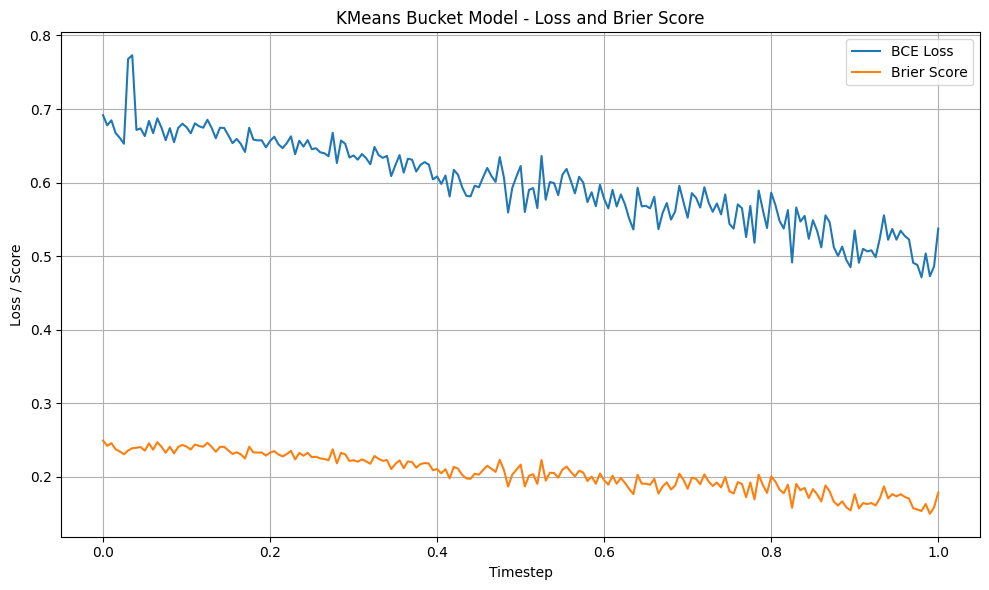

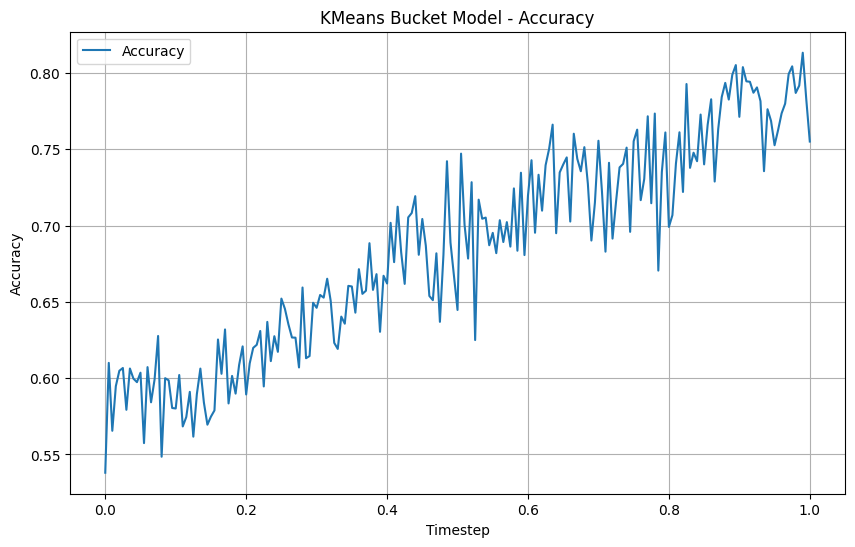

In [18]:
_ = process_data.plot_loss(models, test_data, 'KMeans Bucket Model')
_ = process_data.plot_accuracy(models, test_data, 'KMeans Bucket Model')


In [21]:
from process_data import write_predictions
write_predictions(
    models,
    interpolated_dir,
    years=test_years,
    history_length=history_length,
    features=features,
    replace_nan_val=0,
    phat_b='kmeans_phat_b',
)


Loading data for 2025
Processed file:  game_401772888.csv
Processed file:  game_401772863.csv
Processed file:  game_401772877.csv
Processed file:  game_401772730.csv
Processed file:  game_401772724.csv
Processed file:  game_401772718.csv
Processed file:  game_401772917.csv
Processed file:  game_401772903.csv
Processed file:  game_401772902.csv
Processed file:  game_401772916.csv
Processed file:  game_401772719.csv
Processed file:  game_401772725.csv
Processed file:  game_401772731.csv
Processed file:  game_401772876.csv
Processed file:  game_401772862.csv
Processed file:  game_401772889.csv
Processed file:  game_401772848.csv
Processed file:  game_401772874.csv
Processed file:  game_401772860.csv
Processed file:  game_401772727.csv
Processed file:  game_401772733.csv
Processed file:  game_401772928.csv
Processed file:  game_401772900.csv
Processed file:  game_401772914.csv
Processed file:  game_401772915.csv
Processed file:  game_401772901.csv
Processed file:  game_401772929.csv
Proces

In [22]:
import os
import shutil

# Define the ancestor directory and the parent directory
src_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
dest_dir = os.path.abspath(os.path.join(os.getcwd(), "../../"))

# Specify a list of directories to copy
sources = [
    os.path.join(src_dir, "dataset_interpolated_fixed", "2024"),
    os.path.join(src_dir, "dataset_interpolated_fixed", "2025")
]

destination = os.path.join(dest_dir, "test_8", "kmeans_model")

# Iterate through each source and copy
for source in sources:
    if os.path.exists(source):
        # Extract the year/folder name from source
        folder_name = os.path.basename(source)
        
        if os.path.isdir(source):
            shutil.copytree(source, destination, dirs_exist_ok=True)
        else:
            shutil.copy2(source, destination)
        print(f"Copied '{source}' to '{destination}'")
    else:
        print(f"Source '{source}' does not exist")

Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2024' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_8/kmeans_model'
Copied '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/ML/dataset_interpolated_fixed/2025' to '/Users/aly/Documents/University_of_Waterloo/Winter 2025/Research/code/NFL/test_8/kmeans_model'
